In [ ]:

# External imports
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
# Internal imports
from mGST.low_level_jit import cost_function_jax_mps, cost_function_jax
from mGST.trust_region import run_riemannian_optimization, riemannian_gradient_fn
from mGST.typing import TrustRegionOptions, OperatorSchedule
from mGST.visualization import plot_cost_function

from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, GSTConfiguration, get_compressed_perturbed_rep_from_mgst, compute_riemannian_hessian_kraus, get_mgst_tensors_from_psd_representation

backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

In [5]:
num_qubits = 2
dim = 2**num_qubits
kraus_rank = dim**2
state_rank = dim
povm_rank = dim

Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst, kraus_mgst, povm_mgst, state_mgst, prob_matrix, indices_list = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

2026-01-23 15:01:46,405 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2026-01-23 15:01:46,859 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2026-01-23 15:01:46,860 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-01-23 15:01:48,527 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2026-01-23 15:01:48,535 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-01-23 15:01:48,596 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2026-01-23 15:01:52,766:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-01-23 15:01:52,766 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'ja

In [7]:
# Kraus is already perturbed
kraus_tensor_init_jax = jnp.array(kraus_tensor_mgst)
povm_psd_init_jax, state_psd_init_jax = get_compressed_perturbed_rep_from_mgst(povm_mgst, state_mgst)

init_operators_jax = {
    "kraus_tensor_init": kraus_tensor_init_jax,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

initial_cost_value = cost_function_jax_mps(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 6 the new count changed to: 3
at iteration 31 the new count changed to: 4
at iteration 92 the new count changed to: 5
at iteration 153 the new count changed to: 6
at iteration 214 the new count changed to: 7
at iteration 276 the new count changed to: 8
at iteration 338 the new count changed to: 9
at iteration 400 the new count changed to: 10
at iteration 466 the new count changed to: 11
at iteration 532 the new count changed to: 12
at iteration 599 the new count changed to: 13
at iteration 666 the new count changed to: 14
at iteration 733 the new count changed to: 15
Initial cost value: 0.0015131934090420677


In [12]:
num_iterations_all_tr = 2
tr_schedule_verbose = OperatorSchedule.default(num_iterations_all_tr, TrustRegionOptions(num_iterations=10, verbose=True, verbose_cg=True, num_iterations_cg=5))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=1, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=5, theta_cg=None, kappa_cg=None, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=1, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=5, theta_cg=None, kappa_cg=None, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=1, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=5, theta_cg=None, kappa_cg=None, verbose_cg=True))])}

# Optimization

In [9]:
optimized_operators_all_tr, cost_fn_history_all_tr = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_all_tr,
    optimization_schedule=optimization_schedule_all_tr,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-1]: TrustRegionOptions
povm: Schedule:
  [0-1]: TrustRegionOptions
state: Schedule:
  [0-1]: TrustRegionOptions
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.513193e-03. |r∇f(x)|: 1.845351e-03. Radius: 1.00e-01
TCG finished after: 5/5 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 1. f(x): 1.464105e-03. |r∇f(x)|: 1.214754e-05. Radius: 1.00e-01
TCG finished after: 4/5 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Stopping criteria met. 🛑
Optimization finished ✅. 
 Iters: 2. f(x): 1.464103e-03. |r∇f(x)|: 9.939933e-08. Radius: 2.00e-01. Rejections: 0
TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 1.464103e-03. |r∇f(x)|: 7.661932e-03. Radius: 1.00e-01
TCG finished after: 2/5 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x):

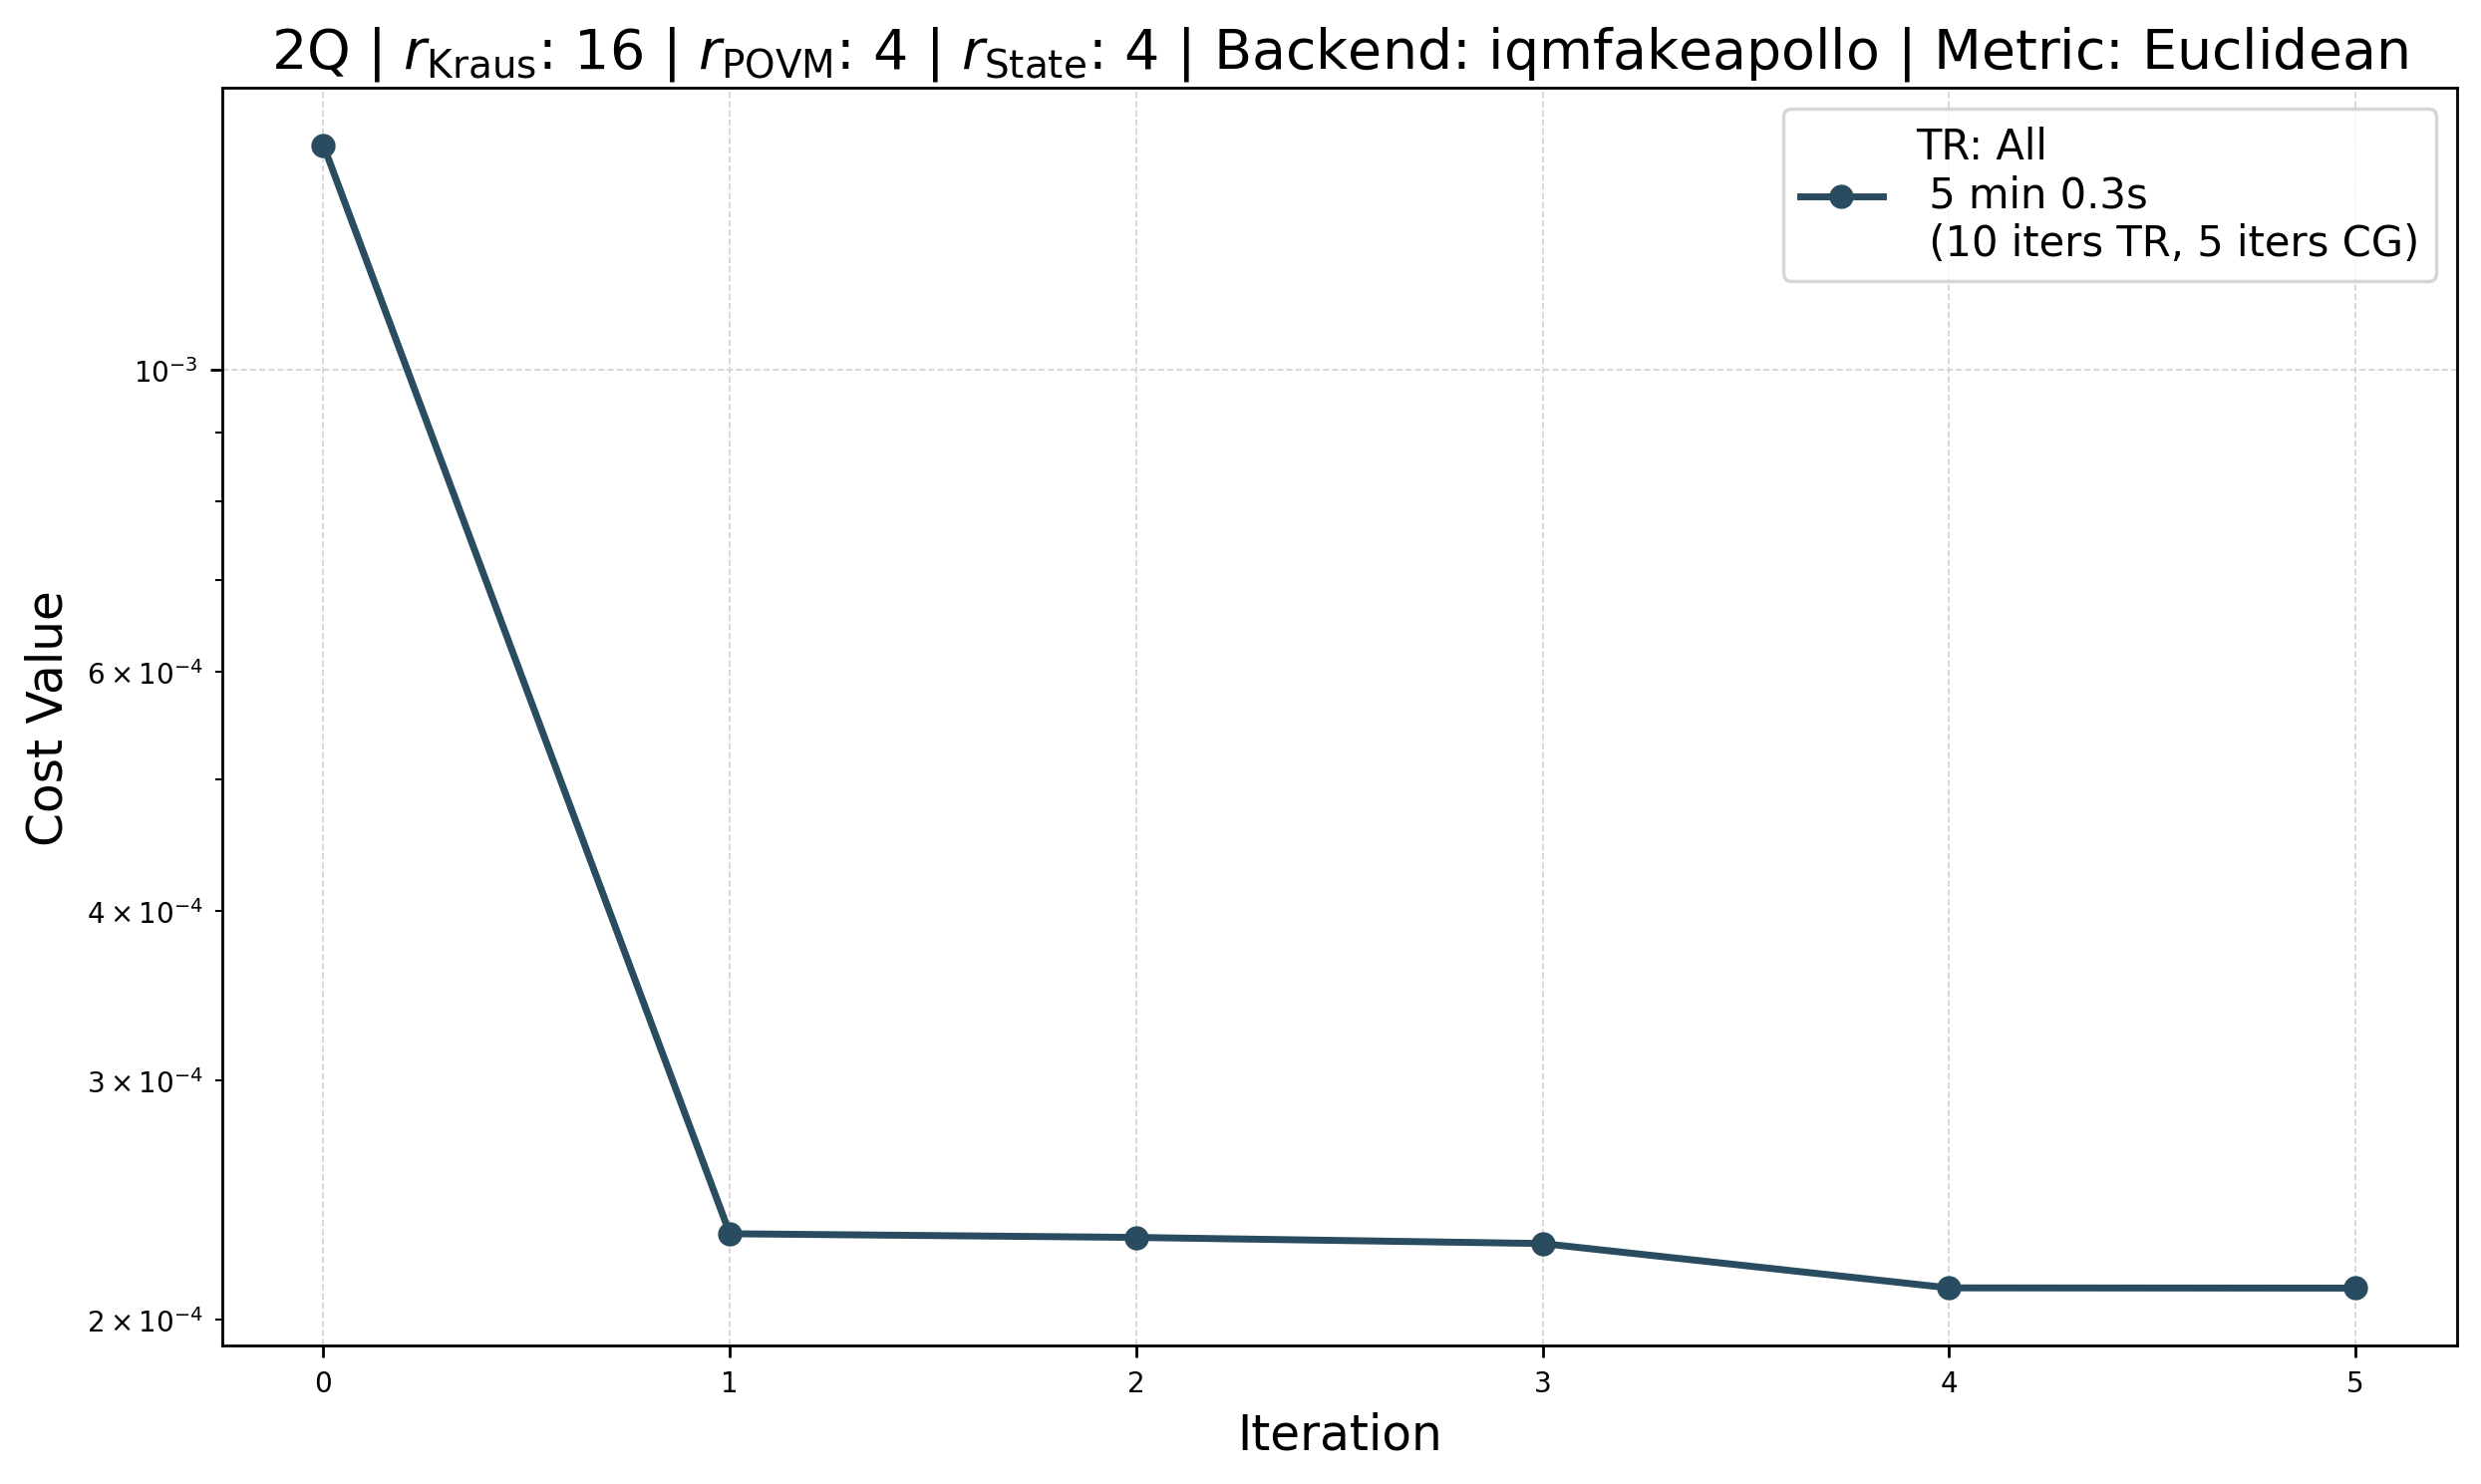

In [11]:
cost_fn_lists = [
    cost_fn_history_all_tr,
]

labels = [
    "TR: All \n 5 min 0.3s \n (10 iters TR, 5 iters CG)",
]

title = rf"{num_qubits}Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Backend: {backend} | Metric: Euclidean"

plot_cost_function(cost_fn_lists, title=title, labels=labels)

# Critical point?

In [19]:
optimized_operators_all_tr.keys()

dict_keys(['kraus', 'povm', 'state'])

In [20]:

kraus_tensor_opt = optimized_operators_all_tr["kraus"]
povm_psd_opt = optimized_operators_all_tr["povm"]
state_psd_opt = optimized_operators_all_tr["state"]

cost_fn_x_povm = lambda x: cost_function_jax_mps(
    kraus_tensor=kraus_tensor_opt, povm_psd=x, state_psd=state_psd_opt, **cost_fn_kwargs)
cost_fn_x_kraus = lambda x: cost_function_jax_mps(
    kraus_tensor=x, povm_psd=povm_psd_opt, state_psd=state_psd_opt, **cost_fn_kwargs)
cost_fn_x_state = lambda x: cost_function_jax_mps(
    kraus_tensor=kraus_tensor_opt, povm_psd=povm_psd_opt, state_psd=x, **cost_fn_kwargs)


In [ ]:
# Sanity check for the cost function at each of these
print("POVM cost:", cost_fn_x_povm(povm_psd_opt))
print("Kraus cost:", cost_fn_x_kraus(kraus_tensor_opt))
print("State cost:", cost_fn_x_state(state_psd_opt))

POVM cost: 0.00021096539759694132
Kraus cost: 0.00021096539759694132
State cost: 0.00021096539759694132


In [23]:
# Compute the gradient for each of the elements.
metric = "euclidean"
grad_povm = riemannian_gradient_fn(x=povm_psd_opt, cost_fn=cost_fn_x_povm, operator_type="povm", metric=metric)
grad_kraus = riemannian_gradient_fn(x=kraus_tensor_opt, cost_fn=cost_fn_x_kraus, operator_type="kraus", metric=metric)
grad_state = riemannian_gradient_fn(x=state_psd_opt, cost_fn=cost_fn_x_state, operator_type="state", metric=metric)

In [24]:
# What is the relative magnitude of these gradients?
norm_grad_povm = jnp.linalg.norm(grad_povm)
norm_grad_kraus = jnp.linalg.norm(grad_kraus)
norm_grad_state = jnp.linalg.norm(grad_state)

norm_povm = jnp.linalg.norm(povm_psd_opt)
norm_kraus = jnp.linalg.norm(kraus_tensor_opt)
norm_state = jnp.linalg.norm(state_psd_opt)

print("Relative gradient norms:")
print("POVM:", norm_grad_povm / norm_povm)
print("Kraus:", norm_grad_kraus / norm_kraus)
print("State:", norm_grad_state / norm_state)

Relative gradient norms:
POVM: 7.710623691107312e-05
Kraus: 5.0090432563823536e-05
State: 5.71312386097968e-08


# Compute Hessian at Critical point

In [ ]:
# Getting the mgst versions of the JAX tensors
mgst_tensors = get_mgst_tensors_from_psd_representation(kraus_tensor_opt, povm_psd_opt, state_psd_opt)

kraus_mgst_opt = np.array(kraus_tensor_opt) # the kraus tensor factorized is all we need for the Hessian computation
kraus_contracted_mgst_opt = mgst_tensors["kraus"]
povm_mgst_opt = mgst_tensors["povm"]
state_mgst_opt = mgst_tensors["state"]

In [34]:
cost_function_jax(kraus_contracted=kraus_contracted_mgst_opt, povm_matrix=povm_mgst_opt, state_vector=state_mgst_opt, indices_list=indices_list, prob_matrix=prob_matrix)

Array(0.00021097, dtype=float64)

In [35]:
rhessian_kraus_mgst, euclidean_derivatives_kraus = compute_riemannian_hessian_kraus(
    kraus_tensor_mgst=kraus_mgst_opt,
    povm_mgst=povm_mgst_opt,
    state_mgst=state_mgst_opt,
    indices_list=indices_list,
    prob_matrix=prob_matrix,
)

Computing 1st and 2nd order Euclidean derivatives ⏳
Computing Riemannian Hessian ⏳


In [ ]:
num_gates, kraus_rank, dim, dim =  kraus_mgst_opt.shape
n = kraus_rank * dim
p = dim
vect_dim = n * p
rhessian_kraus_mgst_mtrx = rhessian_kraus_mgst.reshape(2 * num_gates * vect_dim, 2 * num_gates * vect_dim)
rhessian_kraus_mgst_mtrx.shape

(2560, 2560)

# Look at eigenvalues

In [38]:
reigvals_kraus = jnp.linalg.eigvals(rhessian_kraus_mgst_mtrx)
reigvals_kraus_real = reigvals_kraus.real
reigvals_kraus_imag = reigvals_kraus.imag
jnp.linalg.norm(reigvals_kraus_imag), jnp.linalg.norm(reigvals_kraus_real)

(Array(2.16085361e-16, dtype=float64), Array(0.62408539, dtype=float64))

In [42]:
eigvals_real_all_kraus_ordered = jnp.sort(reigvals_kraus_real)

2026-01-23 17:54:34,249 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral
2026-01-23 17:54:34,303 - matplotlib.mathtext - INFO - Substituting symbol R from STIXGeneral


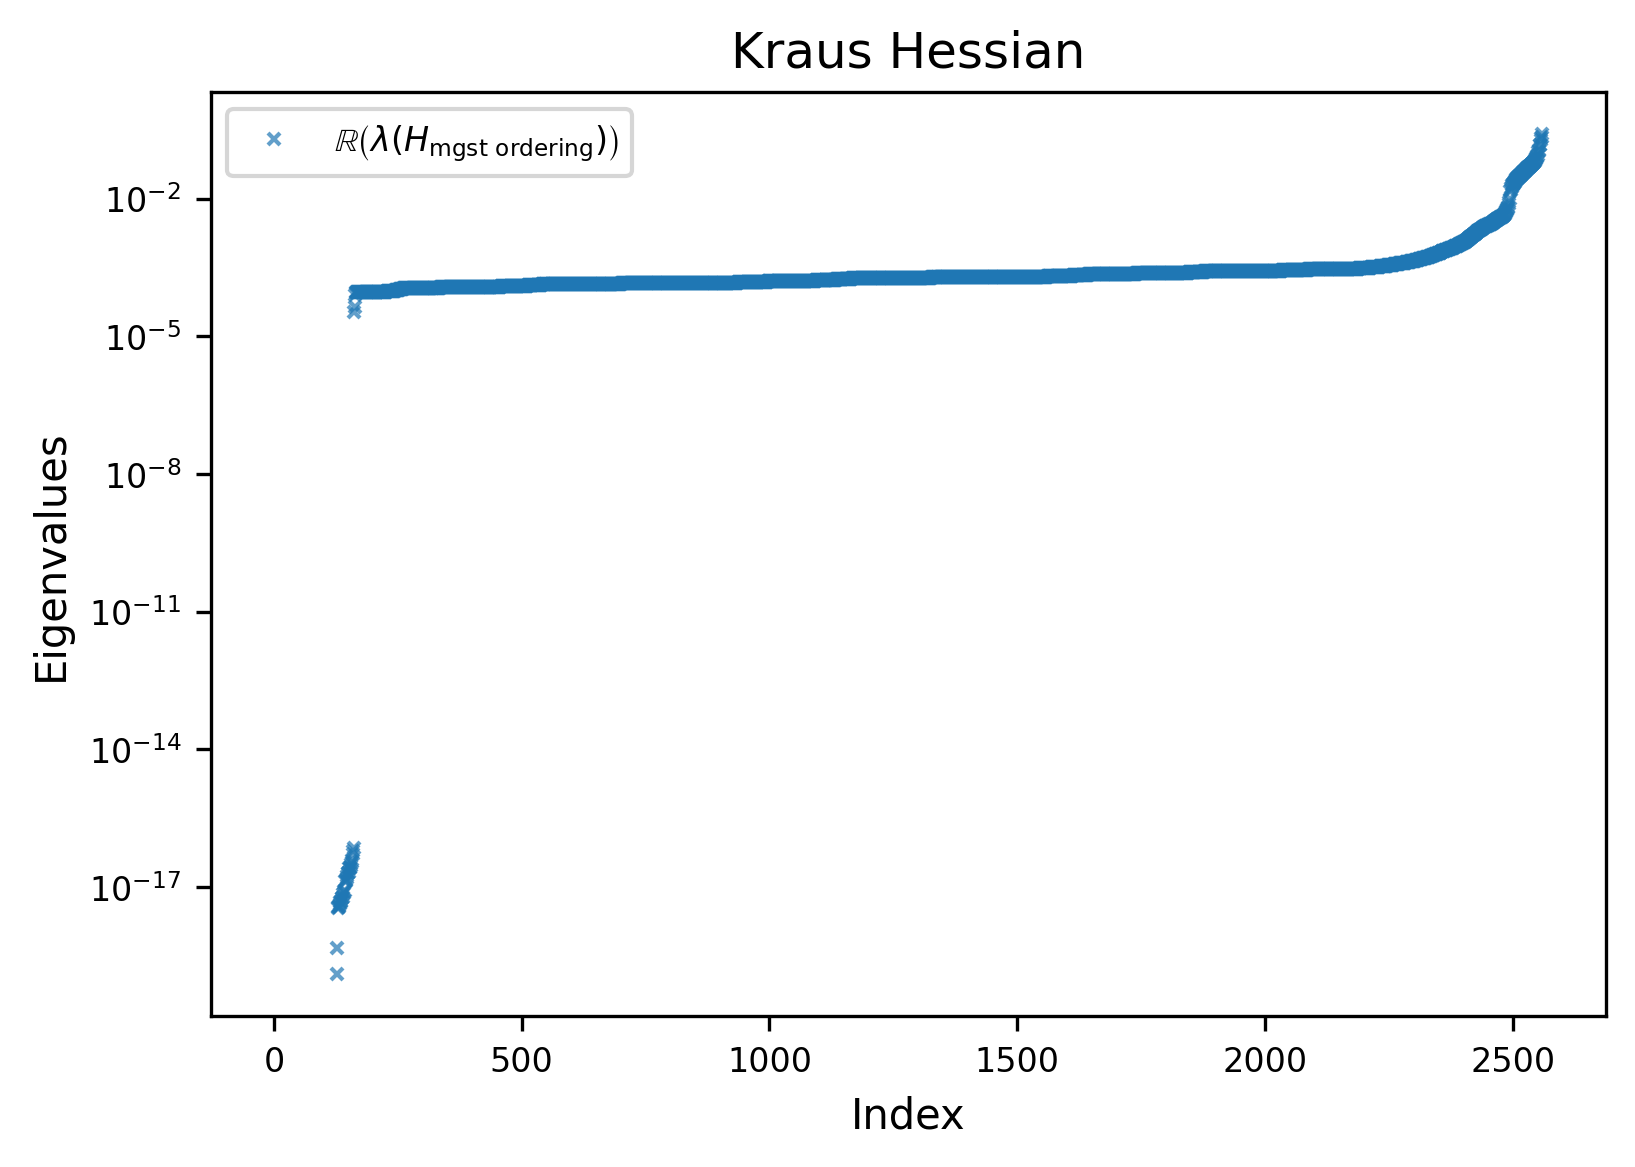

In [43]:
# get the eigenvalues of the hessian
plt.figure(figsize=(6, 4), dpi=300)
plt.title("Kraus Hessian", fontsize=12)
plt.semilogy(eigvals_real_all_kraus_ordered, "x", markersize=3, label=r"$\mathbb{R}\left( \lambda(H_{\text{mgst ordering}}) \right)$", alpha=0.7)
plt.ylabel("Eigenvalues", fontsize=10)
plt.xlabel("Index", fontsize=10)
plt.legend()

In [44]:
jnp.linalg.matrix_rank(rhessian_kraus_mgst_mtrx)

Array(2480, dtype=int64)